# Flight Departure Delay Prediction — LightGBM


## Step 1 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score,
    precision_recall_curve, RocCurveDisplay, average_precision_score
)
from imblearn.over_sampling import SMOTE
import joblib
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)


## Step 2 - Load Data and Analysis

### 2.1 View Dataset

In [2]:
train = pd.read_csv("flight_dataset_v2.csv")

print(f"Training Data")
print(f"Shape: {train.shape}")
print(train.head())
print(train.info())
print(train.describe())

Training Data
Shape: (9754, 51)
  id             airline origin_code destination_code    route aircraft_type  \
0  1  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
1  2  SriLankan Airlines         CMB              BOM  CMB_BOM          A332   
2  3  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
3  4  SriLankan Airlines         CMB              BOM  CMB_BOM          A20N   
4  5  SriLankan Airlines         CMB              BOM  CMB_BOM          A320   

  scheduled_departure_time actual_departure_time scheduled_arrival_time  \
0          12/1/2025 23:40        12/2/2025 1:44         12/2/2025 2:10   
1         11/30/2025 23:40        12/1/2025 2:04         12/1/2025 2:10   
2          11/30/2025 8:28       11/30/2025 8:28       11/30/2025 10:28   
3         11/29/2025 23:40                     0        11/30/2025 2:10   
4         11/28/2025 23:40                     0        11/29/2025 2:10   

  actual_arrival_time  ...  arr_weat

### 2.2 Check Missing Values

In [3]:
train.isna().sum()

id                                   0
airline                              0
origin_code                          0
destination_code                     0
route                                0
aircraft_type                        0
scheduled_departure_time             0
actual_departure_time                0
scheduled_arrival_time               0
actual_arrival_time                  0
departure_delay_min                  0
arrival_delay_min                    0
is_diverted                          0
is_cancelled                         0
is_sri_lankan_public_holiday         0
is_poya_day                          0
is_festival_period                   0
is_post_holiday                      0
is_long_weekend                      0
dep_date_only                        0
scheduled_departure_hour             0
scheduled_arrival_hour               0
scheduled_departure_day_of_week      0
scheduled_arrival_day_of_week        0
scheduled_is_weekend                 0
scheduled_month          

### 2.3 Numerical Data Analysis

In [4]:
numerical_features = ['departure_delay_min', 'arrival_delay_min','scheduled_departure_hour', 
                      'scheduled_arrival_hour', 'scheduled_month','scheduled_flight_duration_min',
                      'dep_wind_speed_10m', 'dep_cloud_cover', 'dep_visibility', 'dep_precipitation', 
                      'dep_weather_code', 'arr_wind_speed_10m', 'arr_cloud_cover', 'arr_visibility', 'arr_precipitation', 'arr_weather_code',
                    'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay',
]

# Descriptive stats
num_stats = train[numerical_features].describe()
print(num_stats)

       departure_delay_min  arrival_delay_min  scheduled_departure_hour  \
count          9754.000000        9754.000000               9754.000000   
mean             16.754972          -3.480623                 12.408550   
std              36.170297          34.758974                  6.020003   
min             -22.000000         -67.000000                  0.000000   
25%               3.000000         -18.000000                  7.000000   
50%              10.000000         -10.000000                 13.000000   
75%              18.000000           1.000000                 17.000000   
max            1012.000000         991.000000                 23.000000   

       scheduled_arrival_hour  scheduled_month  scheduled_flight_duration_min  \
count             9754.000000      9754.000000                    9754.000000   
mean                12.922391         6.660447                     120.174595   
std                  6.029119         3.409617                      62.954616   


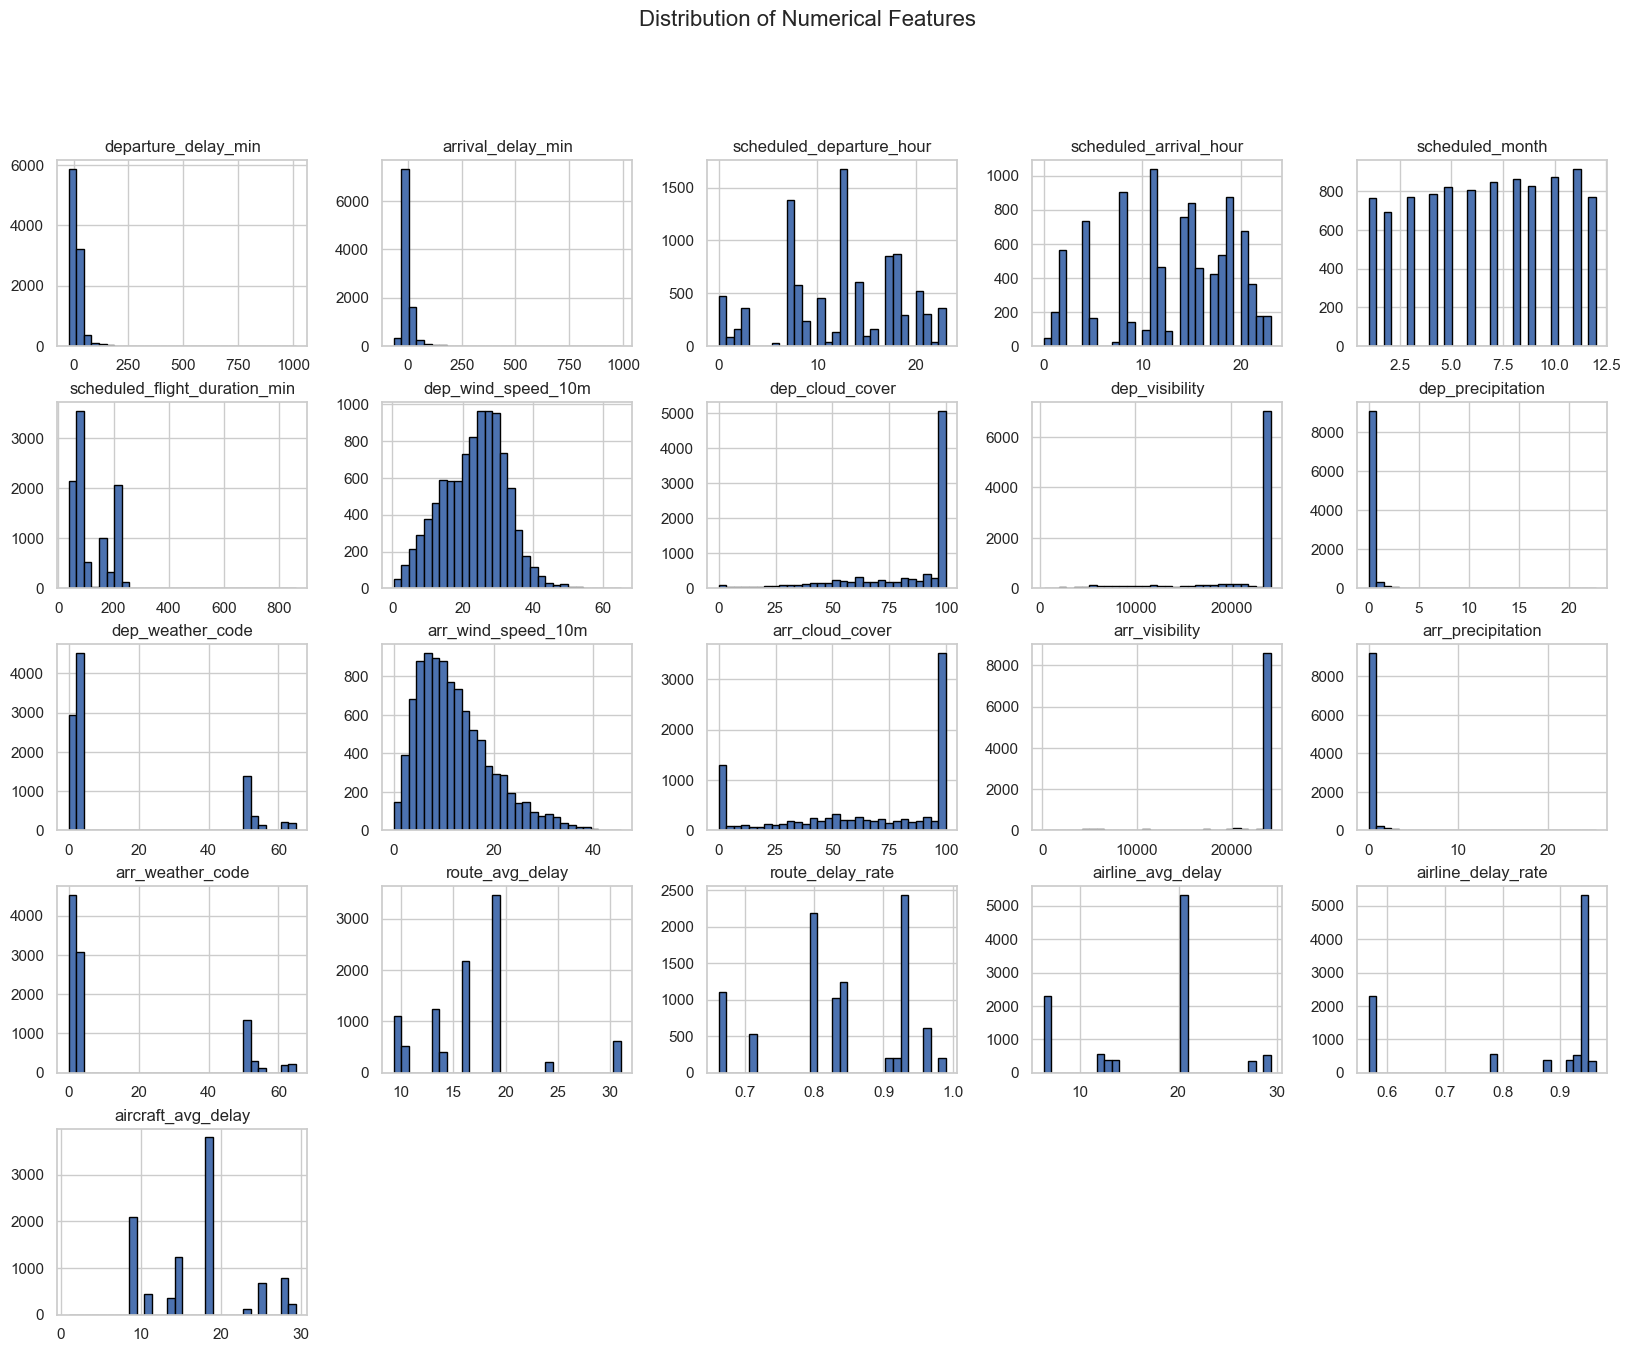

In [5]:
sns.set(style="whitegrid")
numerical_features = ['departure_delay_min', 'arrival_delay_min','scheduled_departure_hour', 
                      'scheduled_arrival_hour', 'scheduled_month','scheduled_flight_duration_min',
                      'dep_wind_speed_10m', 'dep_cloud_cover', 'dep_visibility', 'dep_precipitation', 
                      'dep_weather_code', 'arr_wind_speed_10m', 'arr_cloud_cover', 'arr_visibility', 'arr_precipitation', 'arr_weather_code',
                        'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay']

train[numerical_features].hist(figsize=(20, 15), bins=30, edgecolor='black')
plt.suptitle('Distribution of Numerical Features', fontsize=16)
plt.show()

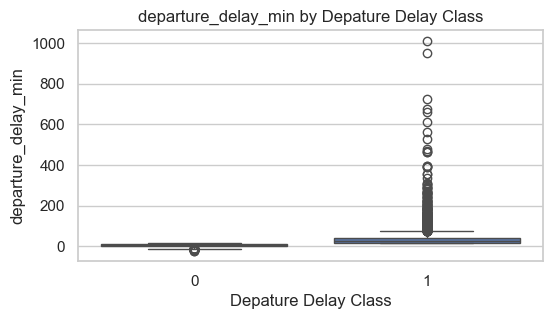

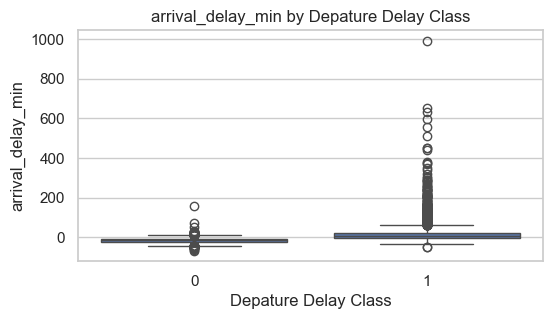

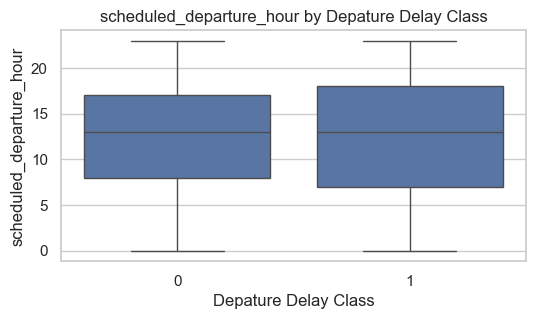

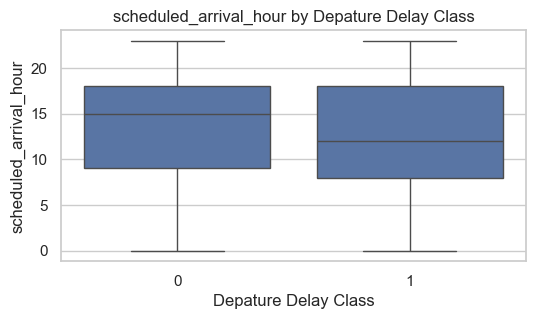

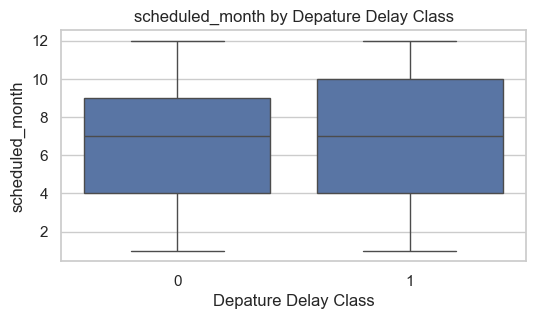

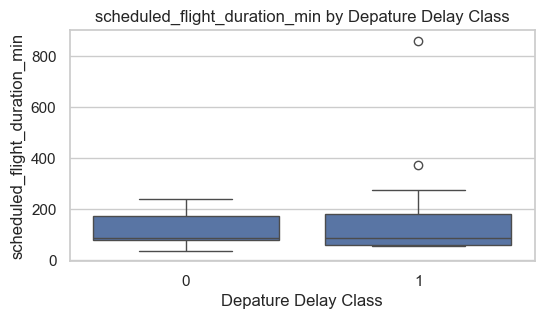

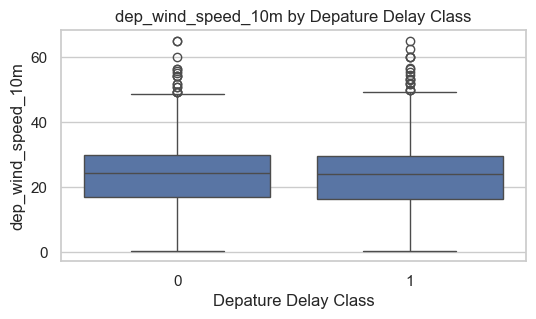

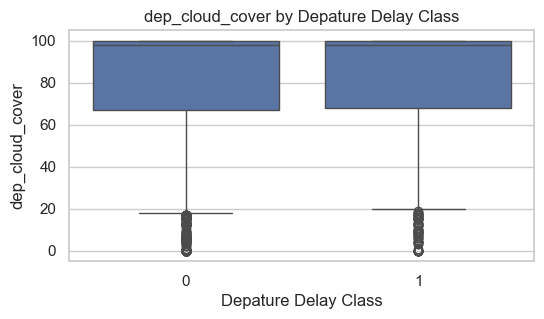

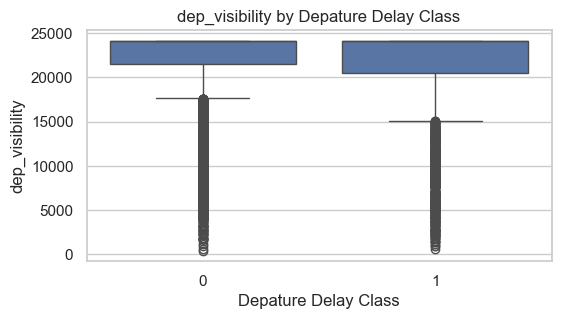

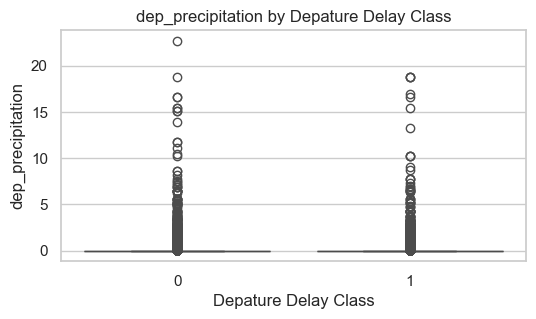

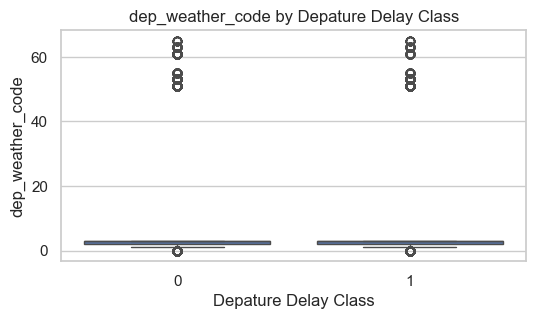

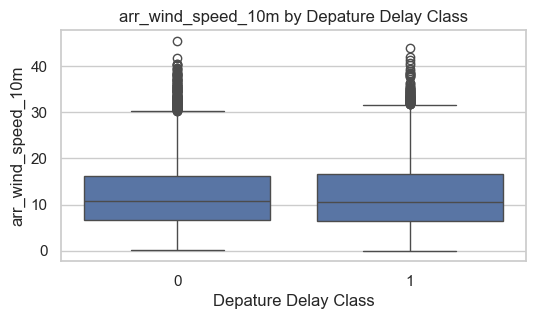

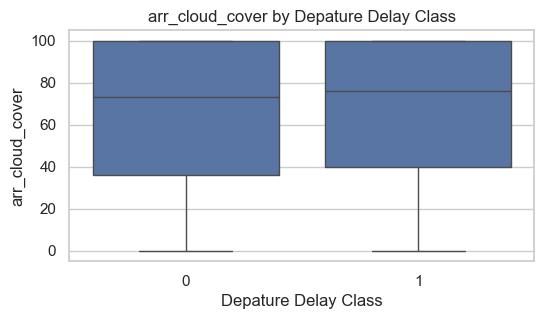

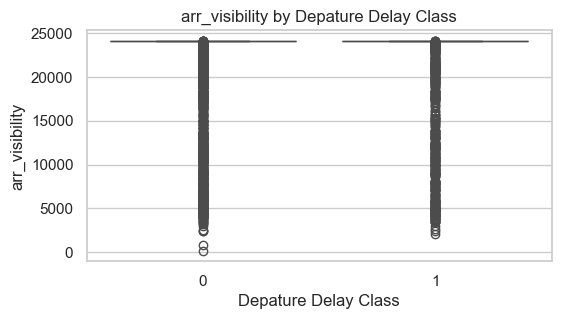

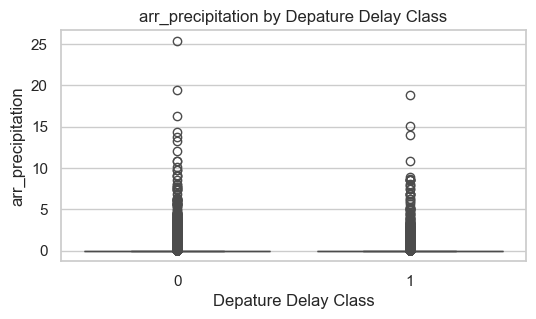

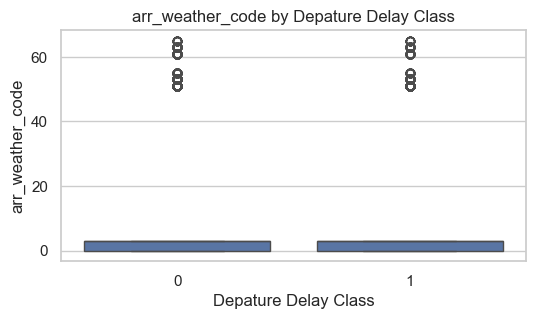

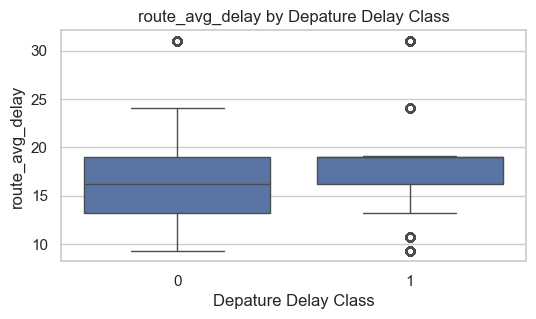

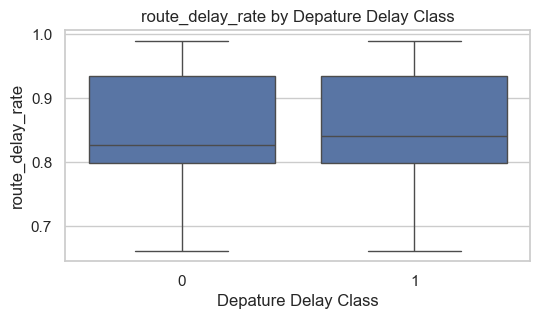

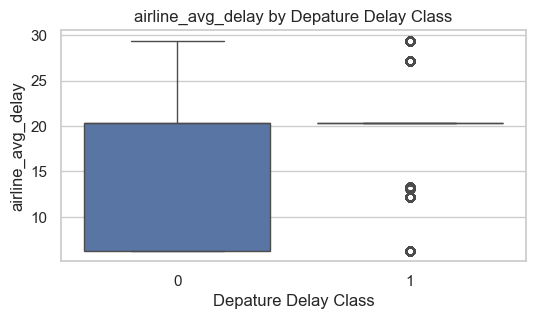

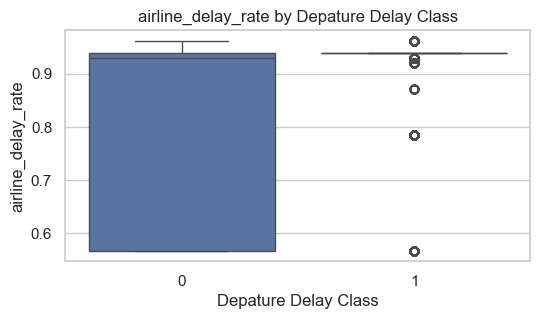

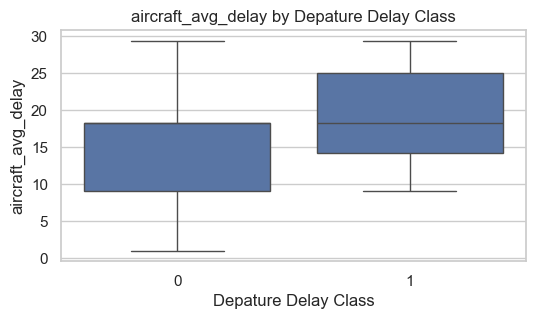

In [6]:
features_to_compare = ['departure_delay_min', 'arrival_delay_min','scheduled_departure_hour', 
                      'scheduled_arrival_hour', 'scheduled_month','scheduled_flight_duration_min',
                      'dep_wind_speed_10m', 'dep_cloud_cover', 'dep_visibility', 'dep_precipitation', 
                      'dep_weather_code', 'arr_wind_speed_10m', 'arr_cloud_cover', 'arr_visibility', 'arr_precipitation', 'arr_weather_code',
                        'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay']

for feature in features_to_compare:
    plt.figure(figsize=(6,3))
    sns.boxplot(x='binary_delay_dep', y=feature, data=train)
    plt.title(f'{feature} by Depature Delay Class')
    plt.xlabel('Depature Delay Class')
    plt.ylabel(feature)
    plt.show()

#### Correlation Matrix

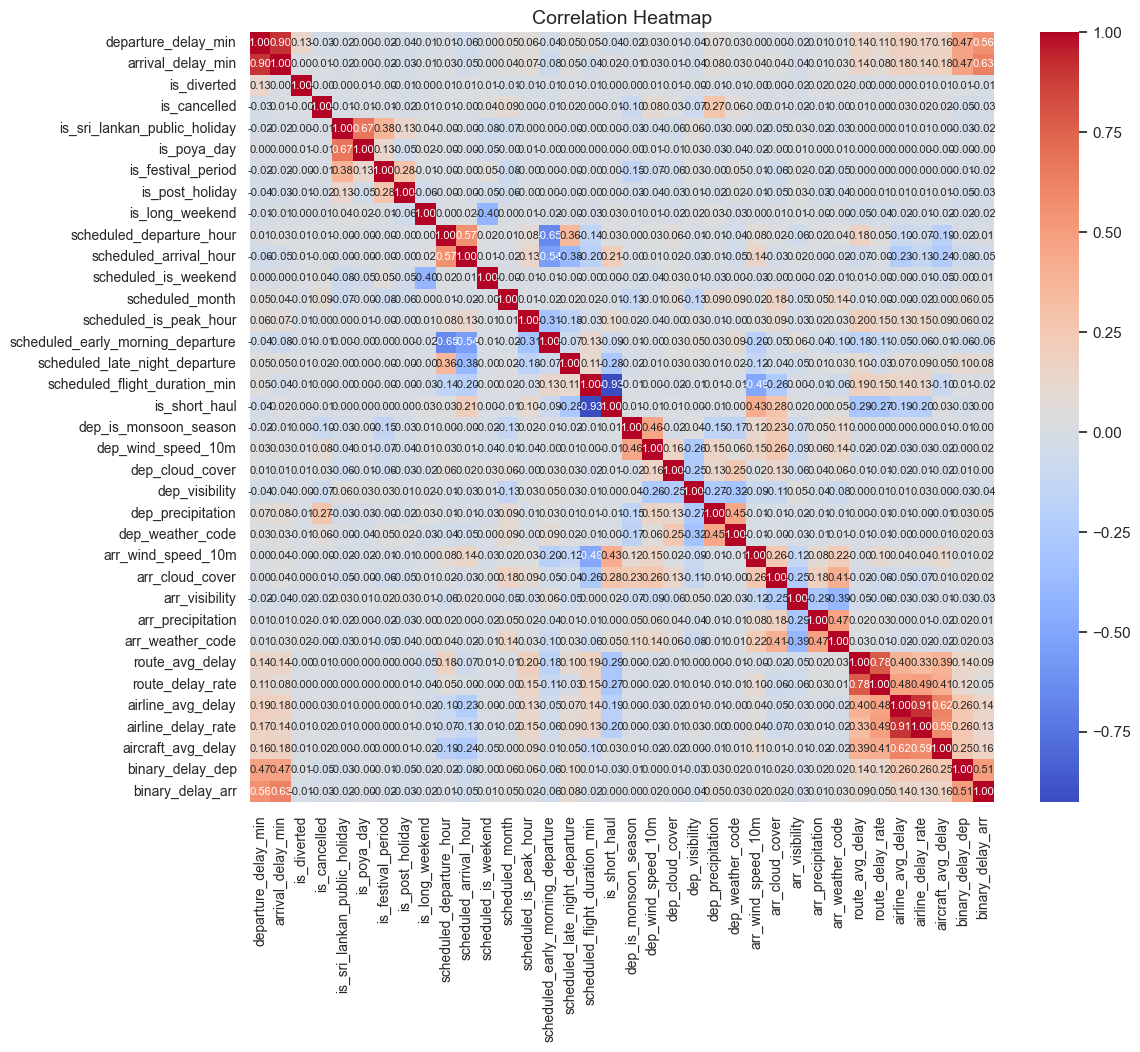

In [7]:
numeric_df = train.select_dtypes(include=['int64', 'float64'])

correlation_matrix = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(
    correlation_matrix, 
    annot=True,          
    fmt=".2f",           
    cmap='coolwarm',
    cbar=True,
    annot_kws={"size": 8}  
)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.title('Correlation Heatmap', fontsize=14)
plt.show()

### 2.4 Categorical Data Analysis

In [8]:
# categorical_features = [
#     "gender",
#     "ethnicity",
#     "education_level",
#     "income_level",
#     "smoking_status",
#     "employment_status"
# ]

# numerical_features = [
#     col for col in train.columns if col not in categorical_features
# ]

# for feature in categorical_features:
#     print(train[feature].value_counts())
    
# categorical_features = ['gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status']

# for feature in categorical_features:
#     plt.figure(figsize=(7,4))
#     sns.countplot(x=feature, data=train)
#     plt.title(f'Distribution of {feature}')
#     plt.xticks(rotation=45)
#     plt.show()

### 2.5 Analysis Target Variable


Class Distribution (Training Data):
  Not Delayed: 6,514 samples (66.78%)
  Delayed: 3,240 samples (33.22%)


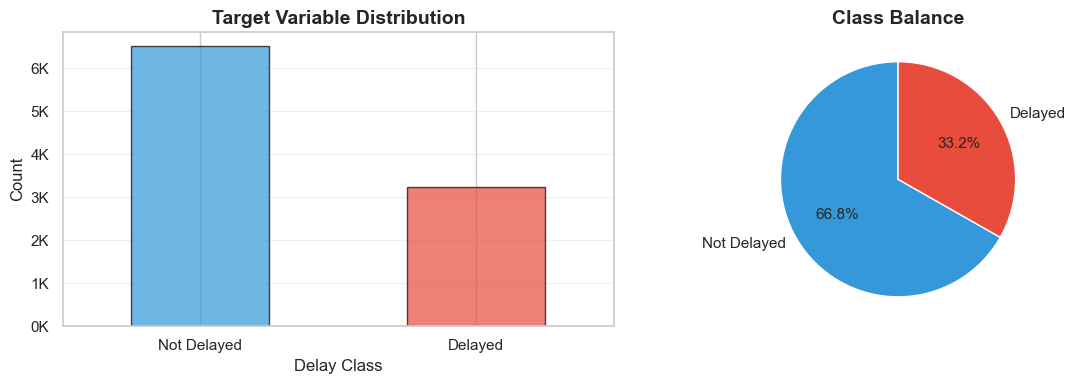

In [9]:
target_counts = train['binary_delay_dep'].value_counts()
target_pct = train['binary_delay_dep'].value_counts(normalize=True) * 100

print(f"\nClass Distribution (Training Data):")
for idx in sorted(train['binary_delay_dep'].unique()):
    count = target_counts[idx]
    pct = target_pct[idx]
    label = "Delayed" if idx == 1 else "Not Delayed"
    print(f"  {label}: {count:,} samples ({pct:.2f}%)")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
target_counts.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c'], alpha=0.7, edgecolor='black')
axes[0].set_title('Target Variable Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Delay Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Not Delayed','Delayed'], rotation=0)
axes[0].grid(axis='y', alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}K'))

# Pie chart
axes[1].pie(target_counts, labels=[ 'Not Delayed','Delayed'], autopct='%1.1f%%',
            colors=['#3498db', '#e74c3c'], startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Class Balance', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Step 3 — Preprocessing & Feature Engineering

### 3.1 Drop Columns

In [10]:
# ── Remove cancelled & diverted (no real delay value) ───────────────────────
print(f"Cancelled : {train['is_cancelled'].sum()} rows removed")
print(f"Diverted  : {train['is_diverted'].sum()} rows removed")

df = train[
    (train['is_cancelled'] == 0) &
    (train['is_diverted']  == 0)
].copy().reset_index(drop=True)

print(f"\nClean shape: {df.shape}")

# ── Verify target ────────────────────────────────────────────────────────────
print(f"\ndeparture_delay_min range: [{df['departure_delay_min'].min()}, {df['departure_delay_min'].max()}]")
print(f"Negative delays: {(df['departure_delay_min'] < 0).sum()}  (early departures — treat as 0)")
df['departure_delay_min'] = df['departure_delay_min'].clip(lower=0)

Cancelled : 52 rows removed
Diverted  : 10 rows removed

Clean shape: (9692, 51)

departure_delay_min range: [-22, 1012]
Negative delays: 1269  (early departures — treat as 0)


In [11]:
drop_cols = [
    'id', 'dep_date_only',
    'actual_departure_time', 'actual_arrival_time',
    'departure_delay_min', 'arrival_delay_min',
    'binary_delay_arr', 
    'delay_class_dep', 
    'delay_class_arr',
    'scheduled_departure_time', 'scheduled_arrival_time',
    'origin_code',
    'is_diverted', 'is_cancelled',
    # 'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay'
]

df = train.drop(columns=[c for c in drop_cols if c in train.columns])

print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")


Shape after dropping: (9754, 37)
Remaining columns: ['airline', 'destination_code', 'route', 'aircraft_type', 'is_sri_lankan_public_holiday', 'is_poya_day', 'is_festival_period', 'is_post_holiday', 'is_long_weekend', 'scheduled_departure_hour', 'scheduled_arrival_hour', 'scheduled_departure_day_of_week', 'scheduled_arrival_day_of_week', 'scheduled_is_weekend', 'scheduled_month', 'scheduled_is_peak_hour', 'scheduled_early_morning_departure', 'scheduled_late_night_departure', 'scheduled_flight_duration_min', 'is_short_haul', 'dep_is_monsoon_season', 'dep_wind_speed_10m', 'dep_cloud_cover', 'dep_visibility', 'dep_precipitation', 'dep_weather_code', 'arr_wind_speed_10m', 'arr_cloud_cover', 'arr_visibility', 'arr_precipitation', 'arr_weather_code', 'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay', 'binary_delay_dep']


### 3.2 Feature Engineering

In [12]:
def feature_engineering(df):

    # drop_cols = [
    #     'id', 'dep_date_only',
    #     'actual_departure_time', 'actual_arrival_time',
    #     'departure_delay_min', 'arrival_delay_min',
    #     'binary_delay_arr',
    #     'delay_class_dep', 'delay_class_arr',
    #     'scheduled_departure_time', 'scheduled_arrival_time',
    #     'origin_code', 'is_diverted', 'is_cancelled'
    # ]

    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # Cyclical Hour
    for col, prefix in [
        ('scheduled_departure_hour','dep'),
        ('scheduled_arrival_hour','arr')
    ]:
        if col in df.columns:
            df[f'{prefix}_hour_sin'] = np.sin(2*np.pi*df[col]/24)
            df[f'{prefix}_hour_cos'] = np.cos(2*np.pi*df[col]/24)

    # Cyclical Month
    if 'scheduled_month' in df.columns:
        df['month_sin'] = np.sin(2*np.pi*df['scheduled_month']/12)
        df['month_cos'] = np.cos(2*np.pi*df['scheduled_month']/12)

    # Day of week cyclical
    day_map = {
        'Monday':0,'Tuesday':1,'Wednesday':2,
        'Thursday':3,'Friday':4,
        'Saturday':5,'Sunday':6
    }

    for col in [
        'scheduled_departure_day_of_week',
        'scheduled_arrival_day_of_week'
    ]:
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].map(day_map)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[f'{col}_sin'] = np.sin(2*np.pi*df[col]/7)
            df[f'{col}_cos'] = np.cos(2*np.pi*df[col]/7)

    # Weather features
    if 'dep_precipitation' in df.columns and 'arr_precipitation' in df.columns:
        df['total_precipitation'] = df['dep_precipitation'] + df['arr_precipitation']
        df['any_precipitation'] = (
            (df['dep_precipitation'] > 0) |
            (df['arr_precipitation'] > 0)
        ).astype(int)

    if 'dep_visibility' in df.columns:
        df['dep_weather_risk'] = (
            df['dep_precipitation'] +
            df['dep_cloud_cover']/100 -
            df['dep_visibility']/50000
        )

    if 'arr_visibility' in df.columns:
        df['arr_weather_risk'] = (
            df['arr_precipitation'] +
            df['arr_cloud_cover']/100 -
            df['arr_visibility']/50000
        )

    if 'scheduled_late_night_departure' in df.columns and 'dep_is_monsoon_season' in df.columns:
        df['night_monsoon'] = (
            df['scheduled_late_night_departure'] *
            df['dep_is_monsoon_season']
        )

    return df
    # Cyclical Hour
   
# # ── Cyclical hour encoding ──────────────────────────────────────────────────
# for col, prefix in [('scheduled_departure_hour','dep'), ('scheduled_arrival_hour','arr')]:
#     if col in df.columns:
#         df[f'{prefix}_hour_sin'] = np.sin(2 * np.pi * df[col] / 24)
#         df[f'{prefix}_hour_cos'] = np.cos(2 * np.pi * df[col] / 24)

# # ── Day of week: string → int → cyclical ────────────────────────────────────
# day_map = {'Monday':0,'Tuesday':1,'Wednesday':2,'Thursday':3,
#            'Friday':4,'Saturday':5,'Sunday':6}
# for col in ['scheduled_departure_day_of_week','scheduled_arrival_day_of_week']:
#     if col in df.columns:
#         if df[col].dtype == object:
#             df[col] = df[col].map(day_map)
#         df[col] = pd.to_numeric(df[col], errors='coerce')
#         df[f'{col}_sin'] = np.sin(2 * np.pi * df[col] / 7)
#         df[f'{col}_cos'] = np.cos(2 * np.pi * df[col] / 7)

# # ── Interaction features ─────────────────────────────────────────────────────
# if all(c in df.columns for c in ['dep_precipitation','arr_precipitation']):
#     df['total_precipitation'] = df['dep_precipitation'] + df['arr_precipitation']
#     df['any_precipitation']   = ((df['dep_precipitation'] > 0) | (df['arr_precipitation'] > 0)).astype(int)

# if all(c in df.columns for c in ['scheduled_late_night_departure','dep_is_monsoon_season']):
#     df['night_monsoon'] = df['scheduled_late_night_departure'] * df['dep_is_monsoon_season']

# if all(c in df.columns for c in ['airline_delay_rate','route_delay_rate']):
#     df['airline_route_risk'] = df['airline_delay_rate'] * df['route_delay_rate']

# if all(c in df.columns for c in ['route_avg_delay','scheduled_is_peak_hour']):
#     df['route_delay_peak'] = df['route_avg_delay'] * df['scheduled_is_peak_hour']

# print("Feature engineering complete ✅")
# print(f"Total columns: {df.shape[1]}")

## Step 4 - Define Target & Features

In [13]:
df = feature_engineering(train.copy())
TARGET = "binary_delay_dep"
X = df.drop(columns=[TARGET])
y = df[TARGET]


categorical_features = [
    'airline',
    'aircraft_type',
    'destination_code',
    'route',
    'scheduled_departure_day_of_week',
    'scheduled_arrival_day_of_week'
]

for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')



# Drop any remaining datetime or object columns
bad_cols = X.select_dtypes(include=['datetime64','object']).columns.tolist()
if bad_cols:
    print(f" Dropping non-numeric columns: {bad_cols}")
    X = X.drop(columns=bad_cols)
    categorical_features = [c for c in categorical_features if c not in bad_cols]

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nClass balance: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1")


Feature matrix: (9754, 51)
Target distribution:
binary_delay_dep
0    6514
1    3240
Name: count, dtype: int64

Class balance: 2.01:1


## Step 5 - Train / Validation Split


In [14]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [15]:
## 7. Handle Class Imbalance with SMOTE

In [16]:

# Encode categoricals temporarily for SMOTE (needs numeric input)

neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("Class weight:", scale_pos_weight)

X_train_enc = X_train.copy()
X_valid_enc = X_valid.copy()

le_dict = {}
for col in categorical_features:
    if col in X_train_enc.columns:
        le = LabelEncoder()
        X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
        X_valid_enc[col] = le.transform(X_valid_enc[col].astype(str))
        le_dict[col] = le

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_enc, y_train)

print(f"Before SMOTE : {dict(y_train.value_counts().sort_index())}")
print(f"After  SMOTE : {dict(pd.Series(y_train_res).value_counts().sort_index())}")

# Re-convert to category for LightGBM after SMOTE
X_train_res = pd.DataFrame(X_train_res, columns=X_train_enc.columns)
X_valid_enc = pd.DataFrame(X_valid_enc, columns=X_valid_enc.columns)
for col in categorical_features:
    if col in X_train_res.columns:
        X_train_res[col] = X_train_res[col].astype('category')
        X_valid_enc[col] = X_valid_enc[col].astype('category')

Class weight: 2.0104166666666665
Before SMOTE : {0: np.int64(5211), 1: np.int64(2592)}
After  SMOTE : {0: np.int64(5211), 1: np.int64(5211)}


## Step 6 - Hyperparameter Tuning with Optuna

In [17]:
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
OPTUNA_TRIALS = 12      # increase to 150 for even better results
CV_FOLDS      = 5
EARLY_STOP    = 100

def objective(trial):
    params = {
        'objective':        'binary',
        'metric':           'auc',
        'boosting_type':    'gbdt',
        'verbosity':        -1,
        'seed':             42,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 200),
        'max_depth':        trial.suggest_int('max_depth', 3, 15),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':     trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1':        trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
        'lambda_l2':        trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        'min_split_gain':   trial.suggest_float('min_split_gain', 0.0, 0.3),
    }

    # Cross-validate on SMOTE-resampled training data only
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_res, y_train_res)):
        X_tr  = X_train_res.iloc[tr_idx]
        X_val = X_train_res.iloc[val_idx]
        y_tr  = y_train_res.iloc[tr_idx] if hasattr(y_train_res, 'iloc') else y_train_res[tr_idx]
        y_val = y_train_res.iloc[val_idx] if hasattr(y_train_res, 'iloc') else y_train_res[val_idx]

        dtrain = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=categorical_features)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain,
                             categorical_feature=categorical_features)

        model = lgb.train(
            params, dtrain,
            num_boost_round=500,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(0)]
        )
        preds = model.predict(X_val, num_iteration=model.best_iteration)
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)

print(f"Running Optuna — 16 trials...")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=12, show_progress_bar=True)

print(f"\nBest CV ROC AUC : {study.best_value:.4f}")
print("Best parameters :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Running Optuna — 16 trials...


  0%|          | 0/12 [00:00<?, ?it/s]


Best CV ROC AUC : 0.8760
Best parameters :
  learning_rate: 0.01024173127534964
  num_leaves: 191
  max_depth: 9
  min_child_samples: 12
  feature_fraction: 0.508545949775245
  bagging_fraction: 0.5059508549225745
  bagging_freq: 10
  lambda_l1: 0.0032776579651102593
  lambda_l2: 0.0030817416779419997
  min_split_gain: 0.20811378472435133


## Step7 - Train Final Model

In [18]:
best_params = study.best_params.copy()
best_params.update({
    'objective':     'binary',
    'metric':        'auc',
    'boosting_type': 'gbdt',
    'verbosity':     -1,
    'seed':          RANDOM_STATE,
    'device': 'gpu'
})

dtrain_final = lgb.Dataset(
    X_train_res, label=y_train_res,
    categorical_feature=categorical_features
)
dvalid_final = lgb.Dataset(
    X_valid_enc, label=y_valid,
    reference=dtrain_final,
    categorical_feature=categorical_features
)

# Track best_iteration so we use the right number of trees
callback_records = {}

final_model = lgb.train(
    best_params,
    dtrain_final,
    num_boost_round=2000,         # large ceiling — early stopping controls actual count
    valid_sets=[dvalid_final],
    callbacks=[
        lgb.early_stopping(EARLY_STOP, verbose=True),
        lgb.log_evaluation(100)
    ]
)

best_iter = final_model.best_iteration
print(f"\nBest iteration   : {best_iter}")
print(f"Best valid AUC   : {final_model.best_score['valid_0']['auc']:.4f}")


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.759675
[200]	valid_0's auc: 0.765895
[300]	valid_0's auc: 0.767019
[400]	valid_0's auc: 0.768138
[500]	valid_0's auc: 0.767836
Early stopping, best iteration is:
[440]	valid_0's auc: 0.769235

Best iteration   : 440
Best valid AUC   : 0.7692


## Step 8 - Evaluation on Unseen Validation Set

Default threshold (0.50) → F1: 0.5605
Tuned  threshold (0.4008) → F1: 0.6103


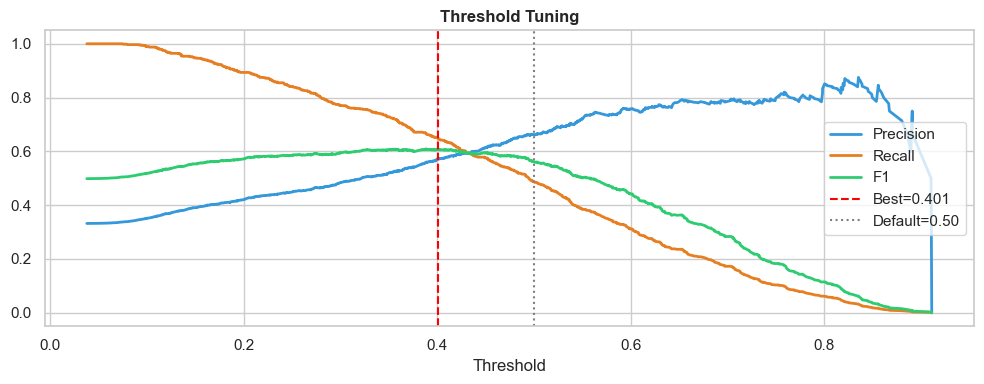

In [19]:
# Predict on truly unseen X_valid
val_probs = final_model.predict(X_valid_enc, num_iteration=best_iter)

# Find optimal threshold via F1 maximisation
precisions, recalls, thresholds = precision_recall_curve(y_valid, val_probs)
f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx   = np.argmax(f1s)
best_thresh = thresholds[best_idx]

print(f"Default threshold (0.50) → F1: {f1_score(y_valid, (val_probs>=0.50).astype(int)):.4f}")
print(f"Tuned  threshold ({best_thresh:.4f}) → F1: {f1s[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#3498db', lw=2)
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#e67e22', lw=2)
ax.plot(thresholds, f1s,             label='F1',        color='#2ecc71', lw=2)
ax.axvline(best_thresh, color='red',  linestyle='--', lw=1.5, label=f'Best={best_thresh:.3f}')
ax.axvline(0.50,        color='gray', linestyle=':',  lw=1.5, label='Default=0.50')
ax.set_xlabel('Threshold'); ax.set_title('Threshold Tuning', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

val_preds_default = (val_probs >= 0.5).astype(int)
val_preds_tuned   = (val_probs >= best_thresh).astype(int)

In [20]:
def print_metrics(y_true, y_pred, y_prob, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  ROC AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  F1 (wtd)  : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['On-Time','Delayed']))

print_metrics(y_valid, val_preds_default, val_probs, "Default Threshold (0.50)")



  Default Threshold (0.50)
  Accuracy  : 0.7468
  ROC AUC   : 0.7692
  F1 (macro): 0.6913
  F1 (wtd)  : 0.7353
  Precision : 0.6618
  Recall    : 0.4861

Classification Report:
              precision    recall  f1-score   support

     On-Time       0.77      0.88      0.82      1303
     Delayed       0.66      0.49      0.56       648

    accuracy                           0.75      1951
   macro avg       0.72      0.68      0.69      1951
weighted avg       0.74      0.75      0.74      1951



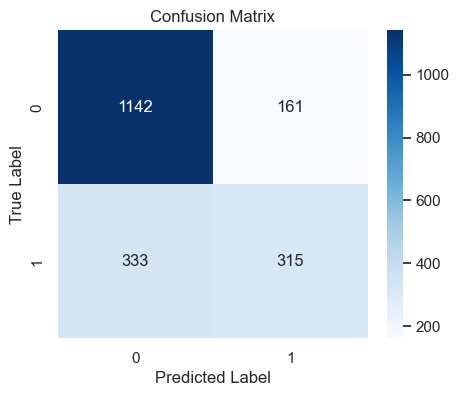

In [21]:
cm = confusion_matrix(y_valid, val_preds_default)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

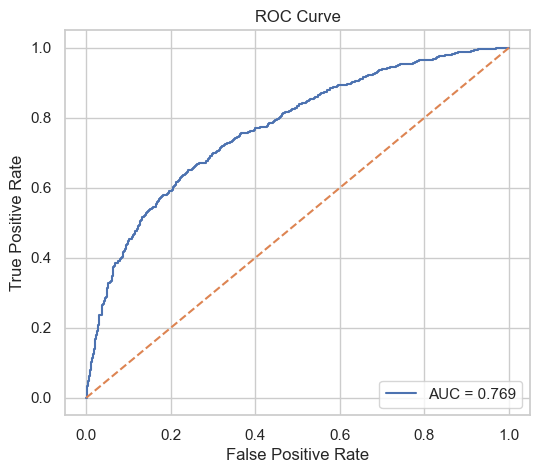

In [25]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve,auc, precision_score, recall_score
)

fpr, tpr, _ = roc_curve(y_valid, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## 12. Feature Importance

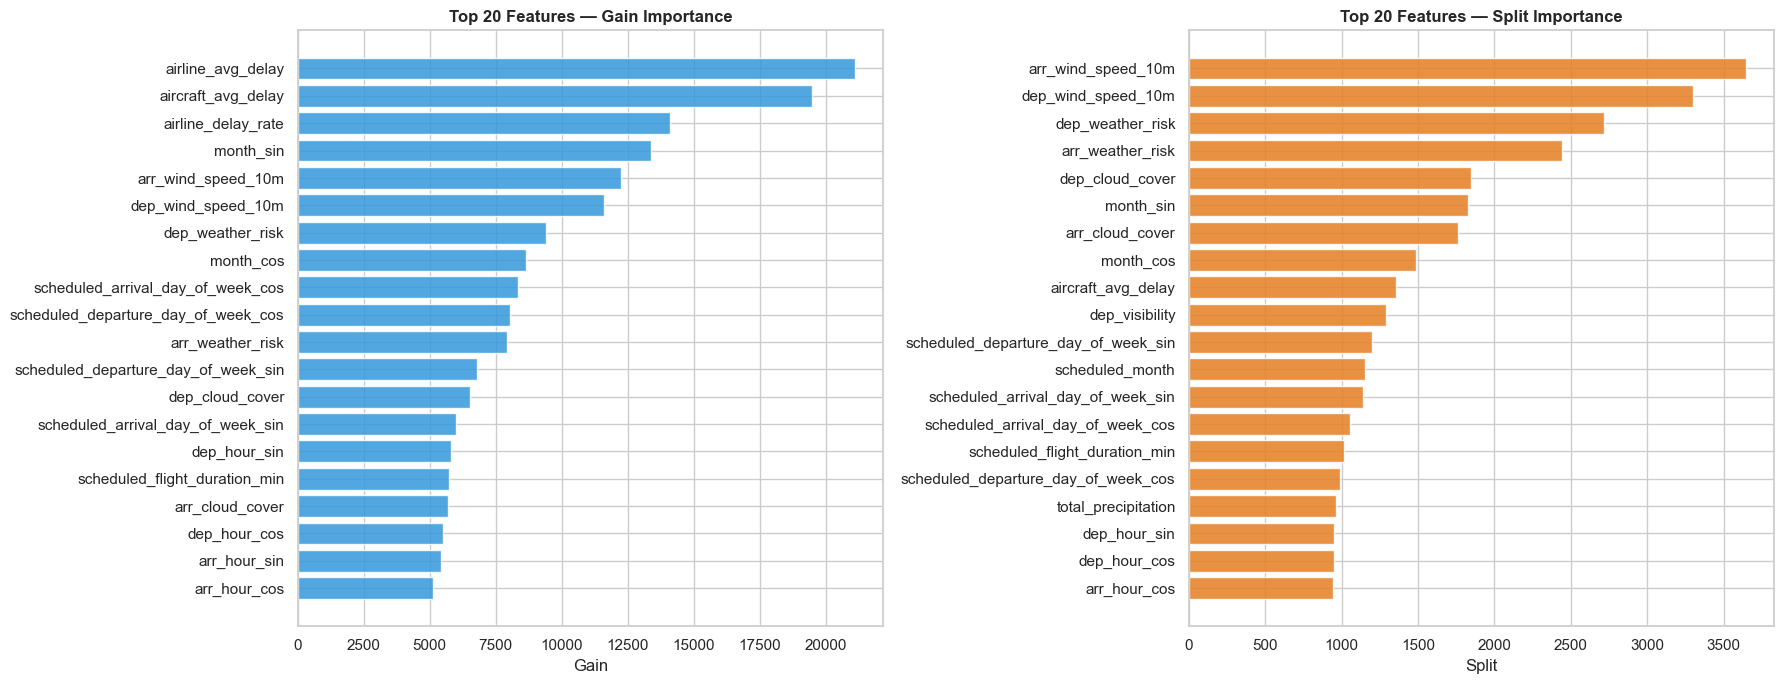

Top 15 features (Gain importance):
airline_avg_delay                      21114.825060
aircraft_avg_delay                     19473.741898
airline_delay_rate                     14107.077033
month_sin                              13397.210732
arr_wind_speed_10m                     12233.868700
dep_wind_speed_10m                     11599.566660
dep_weather_risk                        9400.592093
month_cos                               8651.644093
scheduled_arrival_day_of_week_cos       8331.352913
scheduled_departure_day_of_week_cos     8026.299474
arr_weather_risk                        7913.374626
scheduled_departure_day_of_week_sin     6784.191913
dep_cloud_cover                         6511.699761
scheduled_arrival_day_of_week_sin       5986.334061
dep_hour_sin                            5807.633430


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, importance_type in zip(axes, ['gain', 'split']):
    imp = pd.Series(
        final_model.feature_importance(importance_type=importance_type),
        index=X_train_res.columns
    ).sort_values(ascending=False).head(20)

    bars = ax.barh(imp.index[::-1], imp.values[::-1],
                   color='#3498db' if importance_type=='gain' else '#e67e22',
                   alpha=0.85)
    ax.set_title(f'Top 20 Features — {importance_type.capitalize()} Importance',
                 fontweight='bold')
    ax.set_xlabel(importance_type.capitalize())

plt.tight_layout(); plt.show()

# Print top 15
print("Top 15 features (Gain importance):")
gain_imp = pd.Series(
    final_model.feature_importance(importance_type='gain'),
    index=X_train_res.columns
).sort_values(ascending=False)
print(gain_imp.head(15).to_string())


## 13. Optuna Study Analysis

Optuna plot note: plot_optimization_history() got an unexpected keyword argument 'ax'


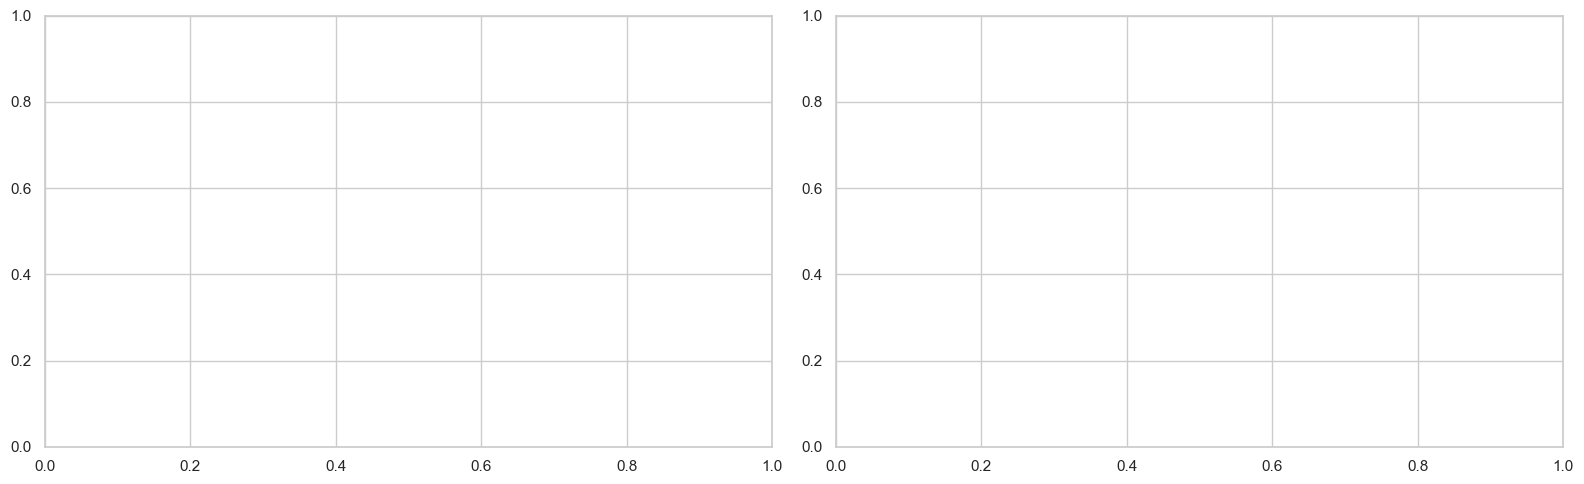


Total trials run : 12
Best trial number: 11
Best CV AUC      : 0.8760


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

try:
    optuna.visualization.matplotlib.plot_optimization_history(study, ax=axes[0])
    axes[0].set_title('Optuna Optimization History', fontweight='bold')

    optuna.visualization.matplotlib.plot_param_importances(study, ax=axes[1])
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
except Exception as e:
    print(f"Optuna plot note: {e}")

plt.tight_layout(); plt.show()

print(f"\nTotal trials run : {len(study.trials)}")
print(f"Best trial number: {study.best_trial.number}")
print(f"Best CV AUC      : {study.best_value:.4f}")


## 14. Results Summary (for Research Report)

In [28]:
summary = pd.DataFrame([{
    'Model':          'LightGBM (Corrected)',
    'Tuning':         f'Optuna ({OPTUNA_TRIALS} trials)',
    'SMOTE':          'Yes',
    'Threshold':      f'{best_thresh:.4f}',
    'Accuracy':       f'{accuracy_score(y_valid, val_preds_tuned):.4f}',
    'ROC AUC':        f'{roc_auc_score(y_valid, val_probs):.4f}',
    'F1 Macro':       f'{f1_score(y_valid, val_preds_tuned, average="macro"):.4f}',
    'F1 Weighted':    f'{f1_score(y_valid, val_preds_tuned, average="weighted"):.4f}',
    'Precision':      f'{precision_score(y_valid, val_preds_tuned, zero_division=0):.4f}',
    'Recall':         f'{recall_score(y_valid, val_preds_tuned, zero_division=0):.4f}',
    'Best Iteration': best_iter,
    'Data Leakage':   'None',
}])

print(summary.T.to_string(header=False))
# summary.to_csv('model_results_summary.csv', index=False)
# print("\nSaved: model_results_summary.csv")


Model           LightGBM (Corrected)
Tuning            Optuna (12 trials)
SMOTE                            Yes
Threshold                     0.4008
Accuracy                      0.7237
ROC AUC                       0.7692
F1 Macro                      0.6981
F1 Weighted                   0.7277
Precision                     0.5741
Recall                        0.6512
Best Iteration                   440
Data Leakage                    None


## 15. Save Model & Config

In [ ]:
# final_model.save_model('lgbm_flight_delay_corrected.txt')

# joblib.dump({
#     'threshold':        best_thresh,
#     'best_iteration':   best_iter,
#     'feature_cols':     list(X_train_res.columns),
#     'categorical_cols': categorical_features,
#     'label_encoders':   le_dict,
#     'optuna_best_params': study.best_params,
#     'optuna_best_auc':  study.best_value,
# }, 'model_config.pkl')

# print("Saved:")
# print("  lgbm_flight_delay_corrected.txt  — LightGBM booster")
# print("  model_config.pkl                 — threshold, features, encoders")


## 16. Inference Helper

In [ ]:
# def predict_delay(model, X_new, config):
#     """
#     Predict flight delay on new data.

#     Parameters
#     ----------
#     model  : loaded LightGBM booster (lgb.Booster)
#     X_new  : DataFrame with same columns as training features
#     config : dict loaded from model_config.pkl

#     Returns
#     -------
#     DataFrame with prediction, probability, and confidence
#     """
#     threshold     = config['threshold']
#     best_iter     = config['best_iteration']
#     le_dict       = config['label_encoders']
#     cat_cols      = config['categorical_cols']
#     feature_cols  = config['feature_cols']

#     X_new = X_new[feature_cols].copy()

#     for col in cat_cols:
#         if col in X_new.columns:
#             X_new[col] = le_dict[col].transform(X_new[col].astype(str))
#             X_new[col] = X_new[col].astype('category')

#     proba = model.predict(X_new, num_iteration=best_iter)
#     preds = (proba >= threshold).astype(int)

#     return pd.DataFrame({
#         'prediction':   preds,
#         'label':        ['Delayed' if p == 1 else 'On-Time' for p in preds],
#         'delay_prob':   proba.round(4),
#         'confidence':   np.where(preds==1, proba, 1-proba).round(4)
#     })

# # ── Example: predict on first 10 validation rows ─────────────────────────────
# config = joblib.load('model_config.pkl')
# loaded_model = lgb.Booster(model_file='lgbm_flight_delay_corrected.txt')
# sample_preds = predict_delay(loaded_model, X_valid_enc.head(10), config)
# print("Sample predictions:")
# print(sample_preds.to_string(index=False))
